### Phase-based encoding in pairwise neural interactions

This notebook reproduces **Figure 1** by simulating two coupled Kuramoto oscillators and quantifying how phase differences encode coupling strength.

Workflow:
1. Configure environment and imports.
2. Simulate trial-wise coupled dynamics.
3. Compute Hilbert / wavelet representations.
4. Estimate coherence and mutual information.
5. Build and save the multi-panel figure.

#### 1) Environment check

This section confirms which Python interpreter is used by the notebook kernel and adds the project root to the Python path so local modules under `src/` can be imported reliably.

In [1]:
# Display the Python executable used by the current notebook kernel.
import os
import sys; print(sys.executable)

/home/INT/brovelli.a/.venvs/main/bin/python


In [2]:
# Add the project root so local modules (e.g., src.models) are importable.
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

#### 2) Imports and dependencies

This cell imports scientific Python libraries, information-theoretic tools from HOI/Frites, and the local Kuramoto simulator used for the synthetic data.

In [3]:
# Import analysis libraries for simulation, time-frequency decomposition, and information metrics.
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import scipy
import xarray as xr
from frites.core import copnorm_nd
from hoi.core import get_mi
from mne.time_frequency import tfr_array_morlet, tfr_array_multitaper
from tqdm import tqdm

from src.models import simulate_kuramoto

/home/INT/brovelli.a/.venvs/main/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import jax
# Check if JAX is using the GPU backend and print the available devices and default backend.
print(jax.devices())   
# This will show the list of devices JAX is using (e.g., GPU, CPU) and confirm the default backend.       
print(jax.default_backend()) 

[CpuDevice(id=0)]
cpu


In [5]:
# Configure consistent font sizes for publication-style figure panels.
SMALL_SIZE = 8
MEDIUM_SIZE = 9
BIGGER_SIZE = 10

plt.rc("font", size=SMALL_SIZE)  # controls default text sizes
plt.rc("axes", titlesize=SMALL_SIZE)  # fontsize of the axes title
plt.rc("axes", labelsize=SMALL_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("figure", titlesize=BIGGER_SIZE)  # fontsize of the figure title

#### 3) Simulation setup

Define oscillator parameters, trial count, and a transient Gaussian-shaped coupling profile whose peak amplitude varies across trials.

In [6]:
# Define model parameters and timeline for Kuramoto simulations.
dt = 0.001  # Integration time-step
fs = 1 / dt
f = 40  # Natural frequency
beta = 2.5  # Noise variance
A = np.array([[0, 1], [0, 0]]).T
ntrials = 1000
time = np.arange(-0.5, 1, 1 / fs)  # Time array
T = time.shape[0]

In [7]:
# Build a Gaussian temporal coupling profile and trial-specific coupling strengths.
s = 8 / (2 * np.pi * f)
# Define the time window for coupling (0 to 0.4 seconds) and create a Gaussian profile centered in that window.
time_start = 0
time_end = 0.4
timestim = time[(time > time_start) & (time < time_end)] - (time_end - time_start) / 2
ind = np.where((time > time_start) & (time < time_end))[0]
gaussian = np.exp(-(timestim**2) / (2 * s**2))
coupling = np.zeros_like(time)
coupling[ind] = gaussian
# Coupling strength array (linearly spaced from 1 to 100)
CS = np.linspace(1, 100, ntrials)
seeds = np.random.randint(0, 100000, ntrials)

In [8]:
# Pre-allocate numpy array so each trial's JAX device buffer is freed immediately
# instead of all 1000 XLA buffers accumulating in a Python list (OOM at ~880 trials).
data = np.empty((ntrials, 2, T), dtype=np.float64)

for trial in tqdm(range(ntrials)):
    result = simulate_kuramoto(
        10 * A,
        np.zeros_like(A),
        coupling * CS[trial],
        f,
        fs,
        beta,
        T,
        seed=seeds[trial],
    )
    # np.asarray() copies the JAX array to numpy and releases the XLA device buffer.
    data[trial] = np.asarray(result)

100%|██████████| 1000/1000 [00:04<00:00, 249.60it/s]


#### 4) Time-frequency transforms and information metrics

Compute the analytic signal, extract wavelet coefficients, estimate coherence, and quantify mutual information between phase differences and coupling labels.

In [9]:
# Compute the analytic signal with the Hilbert transform.
h = scipy.signal.hilbert(data.real, axis=2)

In [10]:
# Compute complex Morlet wavelet coefficients across frequencies.
freqs = np.linspace(0.1, 80, 50)
W = tfr_array_morlet(
    data,
    fs,
    freqs,
    n_cycles=freqs / 4,
    output="complex",
    verbose=None,
)

In [11]:
# Estimate time-frequency coherence from cross- and auto-spectra.
Sxy = (W[:, 0] * np.conj(W[:, 1])).mean(0)
Sxx = (W[:, 0] * np.conj(W[:, 0])).mean(0)
Syy = (W[:, 1] * np.conj(W[:, 1])).mean(0)

# Coherence is the squared magnitude of the cross-spectrum normalized by the product of the auto-spectra.
# Coherence is theoretically bounded in [0, 1].
coh = np.abs(Sxy) ** 2 / (np.real(Sxx) * np.real(Syy))

In [12]:
# Gaussian-copula MI estimator (rank-based, handles non-Gaussian marginals)
mi_fcn = get_mi("gc")

# vmap over time axis, then frequency axis — computes MI at every (freq, time) point
mi_fcn_time = jax.vmap(mi_fcn, in_axes=(2, 2, None, None))
mi_fcn_time_frequency = jax.vmap(mi_fcn_time, in_axes=(2, 2, None, None))

# Cross-spectrum between nodes 0 and 1 (shape: trials × freqs × times)
z = W[:, 0] * np.conj(W[:, 1])

# Phase difference wrapped to [0, π]  (symmetric: |Δθ| carries the coupling signal)
dphi = np.angle(z)
dphi = np.abs((dphi + np.pi) % (2 * np.pi) - np.pi)

# Copula normalisation is skipped here because get_mi("gc") applies it internally
# dphi = copnorm_nd(dphi, axis=0)

# Trial labels: integer rank 0…999 serves as the stimulus variable Y
labels = np.tile(
    np.expand_dims(np.arange(0, ntrials), (1, 2)), (z.shape[1], z.shape[2])
)

# labels = copnorm_nd(labels, axis=0)

# Add features dimension → (1, trials, freqs, times) as expected by the vmapped estimator
dphi   = dphi[np.newaxis, :]
labels = labels[np.newaxis, :]

MI_PHI_gc = mi_fcn_time_frequency(dphi, labels, False, True)

Add a binning method Cell for control analysis

In [13]:
# Control analysis: repeat MI estimation with a histogram binning estimator (6 bins)
# to verify that the GC-MI result is not an artefact of the Gaussian copula assumption.
from hoi.utils import digitize

# Binning estimator — base=2 gives MI in bits; signature differs from gc (no extra flags)
mi_fcn = get_mi("binning", base=2)

# entropy_fcn is already bound inside mi_fcn; returned function takes only (x, y)
mi_fcn_time = jax.vmap(mi_fcn, in_axes=(2, 2))
mi_fcn_time_frequency = jax.vmap(mi_fcn_time, in_axes=(2, 2))

z = W[:, 0] * np.conj(W[:, 1])

# Phase difference wrapped to [0, π]
dphi = np.angle(z)
dphi = np.abs((dphi + np.pi) % (2 * np.pi) - np.pi)

# Discretise into 6 equal-width bins before passing to the binning estimator
dphi = digitize(dphi, n_bins=6)

labels = np.tile(
    np.expand_dims(np.arange(0, ntrials), (1, 2)), (z.shape[1], z.shape[2])
)
labels = digitize(labels, n_bins=6)

# Add features dimension → (1, trials, freqs, times)
dphi   = dphi[np.newaxis, :]
labels = labels[np.newaxis, :]

MI_PHI_bin = mi_fcn_time_frequency(dphi, labels)

#### Trial-shuffle control: making coherence's blindness to Y explicit

Panels E/F already show that coherence and I(Δθ; Y) look different, but a reader has to infer that this is *because* coherence's formula never references Y. To make that explicit, we add a control: shuffle the trial-to-trial correspondence between the coupling trajectory and Y, then compare coherence and I(Δθ; Y) at the natural (peak) frequency for the real vs. shuffled correspondence.

Coherence pools the cross/auto-spectra across trials without ever using Y, so it is *structurally* insensitive to this shuffle — the real and shuffled traces are identical by construction (no extra computation needed). I(Δθ; Y), by contrast, explicitly quantifies the trial-wise dependency between phase difference and Y, so shuffling should collapse it toward its finite-sample floor. This is added as new Panel G, below Panel F.

In [14]:
# Peak (natural) frequency bin, used for the coherence/MI overlay below.
f_idx = np.argmin(np.abs(freqs - f))

rng = np.random.default_rng(0)
label_real = np.arange(ntrials)
label_shuffled = rng.permutation(label_real)

# Coherence at the peak frequency: computed once. Its formula (Sxy, Sxx, Syy
# pooled across trials) never references Y, so it is identical whether Y is
# in its real or shuffled trial order — there is no separate "shuffled" curve.
coh_peak = coh[f_idx, :]

# Phase difference at the peak frequency, reused for both MI estimates below.
z_peak = W[:, 0, f_idx, :] * np.conj(W[:, 1, f_idx, :])
dphi_peak = np.angle(z_peak)
dphi_peak = np.abs((dphi_peak + np.pi) % (2 * np.pi) - np.pi)  # (trials, time)

mi_fcn = get_mi("gc")
mi_fcn_time = jax.vmap(mi_fcn, in_axes=(2, 2, None, None))

x_peak = dphi_peak[np.newaxis, :]                              # (1, trials, time)
y_real = np.tile(label_real[:, None], (1, T))[np.newaxis, :]     # (1, trials, time)
y_shuffled = np.tile(label_shuffled[:, None], (1, T))[np.newaxis, :]

mi_peak_real = np.asarray(mi_fcn_time(x_peak, y_real, False, True)).squeeze()
mi_peak_shuffled = np.asarray(mi_fcn_time(x_peak, y_shuffled, False, True)).squeeze()

#### 5) Figure assembly and export

Create a multi-panel layout, draw simulation/metric panels, annotate them, and export the final figure to PDF.

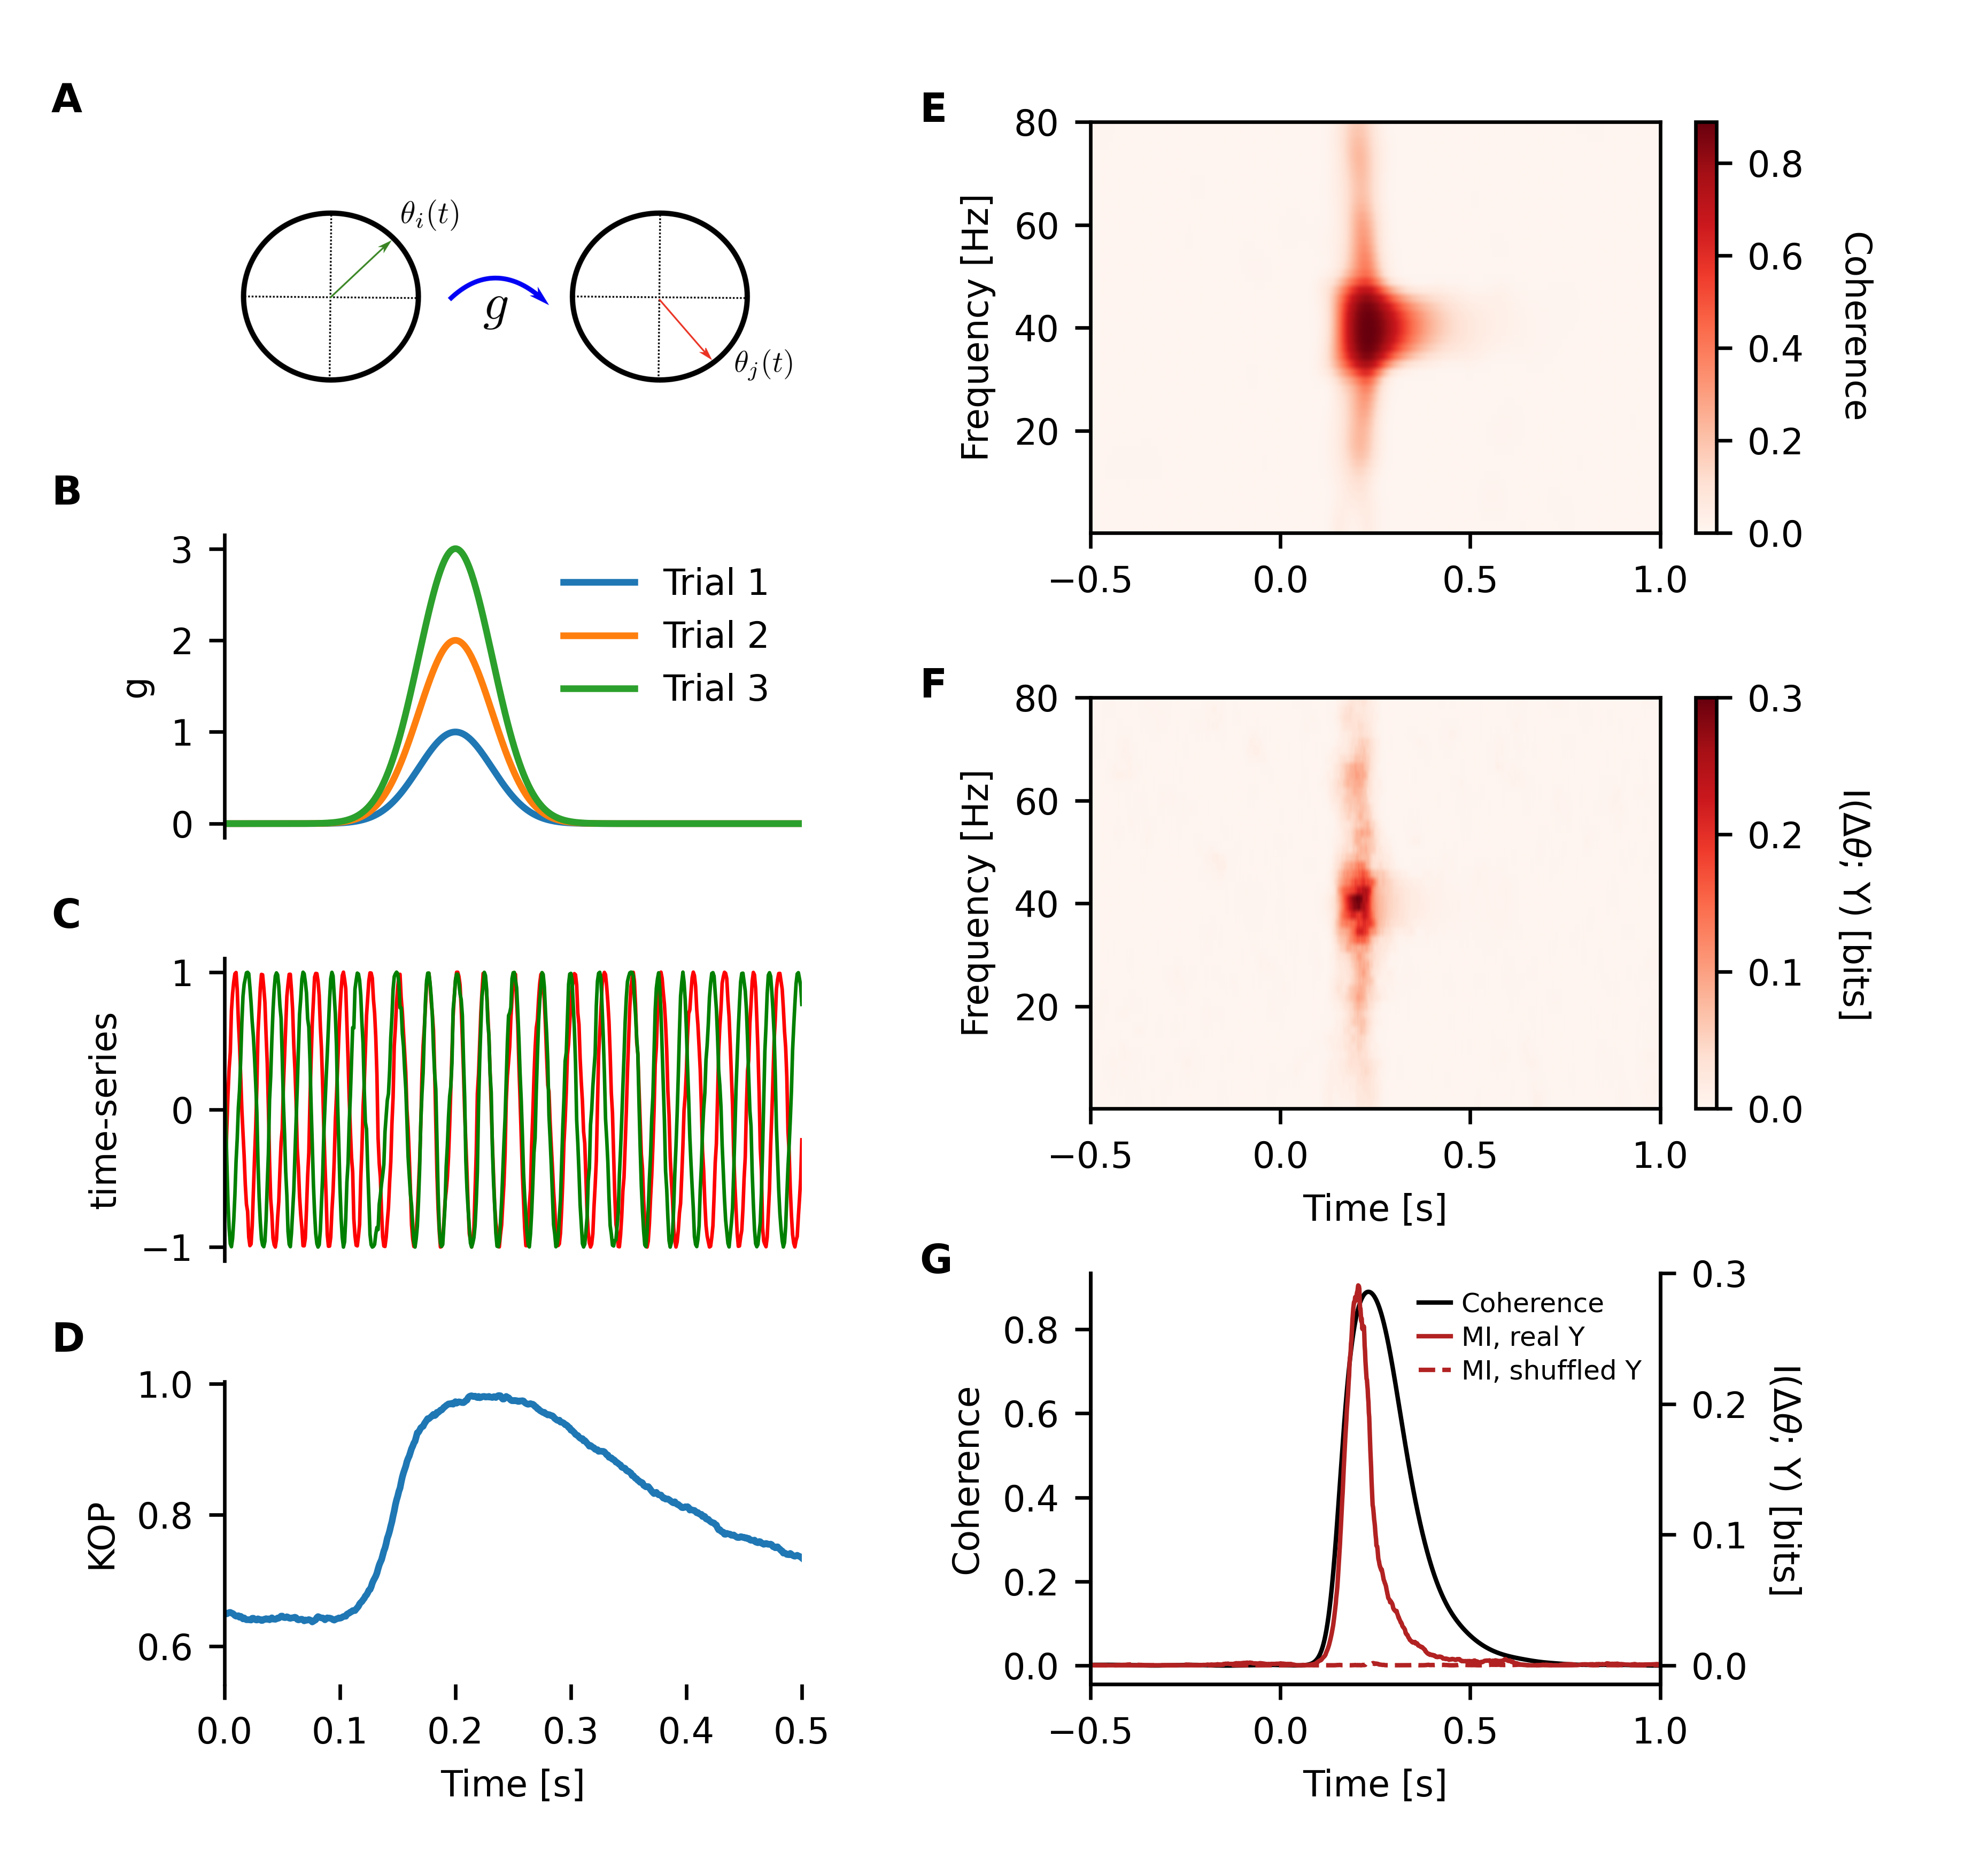

In [49]:
import plot
from PIL import Image

fig = plt.figure(figsize=(6.0, 5.6), dpi=600)

# Left column: gs1 (panel A — cartoon) above gs2 (panels B-D — time series / KOP)
# Right column: gs3 (panels E-F-G — coherence, MI, and trial-shuffle control),
# a single 3-row gridspec so all three rows share the same width, height, and
# inter-row gap (hspace=0.4) — this is what keeps E/F/G equally spaced.
# bottom/top (0.08/0.95) match the left column's overall span (gs1 top / gs2 bottom).
gs1 = fig.add_gridspec(nrows=1, ncols=1, left=0.1, right=0.4, bottom=0.76, top=0.95)
gs2 = fig.add_gridspec(nrows=3, ncols=1, left=0.1, right=0.4,
                       bottom=0.08, top=0.72, hspace=0.4)
gs3 = fig.add_gridspec(nrows=3, ncols=1, left=0.55, right=0.92,
                       bottom=0.08, top=0.95, hspace=0.4)

ax1 = plt.subplot(gs1[0])    # A: cartoon
ax2 = plt.subplot(gs2[0])    # B: coupling profile g(t) for 3 example trials
ax3 = plt.subplot(gs2[1])    # C: time series of node i (strongest coupling trial)
ax5 = plt.subplot(gs2[2])    # D: Kuramoto order parameter (KOP)
ax6 = plt.subplot(gs3[0])    # E: time-frequency coherence spectrogram
ax7 = plt.subplot(gs3[1])    # F: time-frequency MI between Δθ and Y
ax8 = plt.subplot(gs3[2])    # G: trial-shuffle control at the peak frequency

# ── PANEL A: coupling cartoon ────────────────────────────────────────────────
plt.sca(ax1)
im = Image.open("../figures/kuramoto_cartoon.png")
plt.imshow(im)
plt.axis("off")

# ── PANEL B: example coupling profiles for 3 trials ─────────────────────────
plt.sca(ax2)
[plt.plot(time, coupling * i) for i in [1, 2, 3]]
[ax2.spines[key].set_visible(False) for key in ["top", "right", "bottom"]]
plt.legend(["Trial 1", "Trial 2", "Trial 3"], frameon=False)
plt.xticks([])
plt.ylabel("g")
plt.xlim(0, 0.5)

# ── PANEL C: raw time series for the highest-coupling trial ──────────────────
plt.sca(ax3)
plt.plot(time, data[-1].T[:, 0], c="r", lw=0.8)   # node i
plt.xlim(0, 0.5)
plt.xticks([])
[ax3.spines[key].set_visible(False) for key in ["top", "right", "bottom"]]
plt.ylabel("Node $i$")

plt.plot(time, data[-1].T[:, 1], c="g", lw=0.8)   # node j
plt.xlim(0, 0.5)
plt.xticks([])
[ax5.spines[key].set_visible(False) for key in ["top", "right", "bottom"]]
plt.ylabel("time-series")

# ── PANEL D: Kuramoto order parameter (synchrony index) ──────────────────────
plt.sca(ax5)
plt.plot(time, np.abs(h.mean(1)).mean(0))   # mean |KOP| across trials
[ax5.spines[key].set_visible(False) for key in ["top", "right"]]
plt.xlabel("Time [s]")
plt.ylabel("KOP")
plt.xlim(0, 0.5)

# ── PANEL E: time-frequency coherence ────────────────────────────────────────
plt.sca(ax6)
mi_vmax = np.nanpercentile(coh.real, 100)
plt.imshow(
    coh.real,
    aspect="auto",
    origin="lower",
    cmap="Reds",
    extent=[-0.5, 1, 0.1, 80],
    vmin=0,
    vmax=mi_vmax,
)
cbar = plt.colorbar()
cbar.set_label("Coherence", rotation=270, labelpad=15)
plt.xlabel("")
plt.ylabel("Frequency [Hz]")

# ── PANEL F: mutual information I(Δθ; Y) ─────────────────────────────────────
plt.sca(ax7)
mi_phi_plot = np.asarray(MI_PHI_gc).squeeze()
# Guard against all-NaN slices or zero-variance edge cases in the MI map
mi_vmax = np.nanpercentile(mi_phi_plot, 99.5)
if not np.isfinite(mi_vmax) or mi_vmax <= 0:
    mi_vmax = 1e-12

plt.imshow(
    mi_phi_plot,
    aspect="auto",
    origin="lower",
    cmap="Reds",
    extent=[-0.5, 1, 0.1, 80],
    vmin=0,
    vmax=0.3,
)
cbar = plt.colorbar()
cbar.set_label(r"I($\Delta\theta$; Y) [bits]", rotation=270, labelpad=15)
plt.xlabel("Time [s]")
plt.ylabel("Frequency [Hz]")

# ── PANEL G: trial-shuffle control at the peak frequency ─────────────────────
plt.sca(ax8)
l1, = ax8.plot(time, coh_peak, color="k", lw=1)
ax8b = ax8.twinx()
l2, = ax8b.plot(time, mi_peak_real, color="firebrick", lw=1)
l3, = ax8b.plot(time, mi_peak_shuffled, color="firebrick", lw=1, ls="--")
[ax8.spines[key].set_visible(False) for key in ["top"]]
ax8b.spines["top"].set_visible(False)
ax8.set_xlabel("Time [s]")
ax8.set_ylabel("Coherence")
ax8b.set_ylabel(r"I($\Delta\theta$; Y) [bits]", rotation=270, labelpad=12)
ax8.set_xlim(-0.5, 1.0)
# Get current positions of the axes
ax8_pos = ax8.get_position()
# Make the width smaller to match the right edge of ax6 (the coherence panel) so that the three panels line up and share the same x-scale.
right_edge = ax6.get_position().x1
ax8.set_position([ax8_pos.x0, ax8_pos.y0, right_edge - ax8_pos.x0, ax8_pos.height])

# The MI peak sits close enough to t~0.4 that it still brushes the legend's
# bottom-left corner; a little headroom on the MI axis clears it without
# touching the coherence curve's own scale.
y2_min, y2_max = ax8b.get_ylim()
ax8b.set_ylim(y2_min, 0.3)

ax8.legend(
    [l1, l2, l3],
    ["Coherence", "MI, real Y", "MI, shuffled Y"],
    frameon=False, fontsize=SMALL_SIZE - 2, loc="upper right",
    handlelength=1.2, handletextpad=0.4, labelspacing=0.3, borderaxespad=0.3,
)

bg = plot.Background(visible=False)

# Add panel letters to the figure, positioned relative to each axes with ax.text(xmin, ymax, "(a)")
ax1.text(-0.3, 1.3, "A", transform=ax1.transAxes, fontsize=MEDIUM_SIZE, weight="bold")
ax2.text(-0.3, 1.1, "B", transform=ax2.transAxes, fontsize=MEDIUM_SIZE, weight="bold")
ax3.text(-0.3, 1.1, "C", transform=ax3.transAxes, fontsize=MEDIUM_SIZE, weight="bold")
ax5.text(-0.3, 1.1, "D", transform=ax5.transAxes, fontsize=MEDIUM_SIZE, weight="bold")
ax6.text(-0.3, 1., "E", transform=ax6.transAxes, fontsize=MEDIUM_SIZE, weight="bold")
ax7.text(-0.3, 1., "F", transform=ax7.transAxes, fontsize=MEDIUM_SIZE, weight="bold")
ax8.text(-0.3, 1., "G", transform=ax8.transAxes, fontsize=MEDIUM_SIZE, weight="bold")

plt.savefig("../figures/Figure1.pdf")

### Figure caption and interpretation

Figure 1: Phase-based encoding in pairwise neural interactions. (A) Simulation of two Kuramoto oscillators (see Eq. 13; using identical parameters for both nodes: ω = 2π40 Hz, η = 2.5, and coupling strength C12 = 10) coupled via an undirected edge.

The time series of the simulated dynamical system are represented by their instantaneous phases θ(t) (depicted by green and red arrows in the unit circle). The coupling strength g(t) is unidirectional from Xi to Xj.

(B) The coupling strength g(t) between the two nodes was time-modulated such that it was transiently non-zero from 0.1 to 0.3 s, following g(t) = 8Y/(2πf), where Y was the maximum coupling amplitude, increased from 1 to 100 across trials (n = 1000).

(C) Time series of the simulated Kuramoto nodes for the trial with the strongest coupling. (D) Kuramoto order parameter (KOP) time series averaged across trials.

(E) Time-frequency coherence spectrogram between the two nodes computed using wavelet decomposition (n_cycles = fc / 4; for fc ∈ [0.1, 80] Hz). (F) Mutual information between the phase difference of the two nodes (computed from the wavelet coefficients according to Eq. 10) and the coupling amplitudes Y.

(G) Trial-shuffle control at the natural (peak) frequency (f = 40 Hz): coherence (black) is computed once, since its formula pools cross- and auto-spectra across trials without ever referencing Y — it is identical whether Y is in its real or a randomly shuffled trial order. Mutual information (red; solid = real Y, dashed = shuffled Y) collapses toward its finite-sample floor once the true trial-to-trial correspondence between Δθ and Y is broken. This makes explicit, rather than merely implicit in the E/F comparison, that coherence is structurally blind to a coupling-amplitude variable that MI (and PID) can recover.

#### 6) Supplementary Figure 1S — why coherence needs discretized coupling bins

In [16]:
CS = np.linspace(0.1, 10, ntrials)

CS_fixed = 5.0
lag_degrees = {"Lag 0°": 0.0, "Lag 30°": 30.0, "Lag 60°": 60.0}
lag_delays_s = {
    name: np.deg2rad(deg) / (2 * np.pi * f) for name, deg in lag_degrees.items()
}

In [17]:
coupling_tonic = np.ones_like(time)

def simulate_batch(cs_values, seeds, D=None):
    D = np.zeros_like(A, dtype=float) if D is None else D
    out = np.empty((len(cs_values), 2, T), dtype=np.float64)
    for trial in tqdm(range(len(cs_values))):
        result = simulate_kuramoto(
            10 * A,
            D,
            coupling_tonic * cs_values[trial],
            f,
            fs,
            beta,
            T,
            seed=seeds[trial],
        )
        out[trial] = np.asarray(result)
    return out

data_gt = simulate_batch(CS, seeds)

third = ntrials // 3
group_sizes = [third, third, ntrials - 2 * third]

blocks = []
seed_cursor = 0
for delay_s, size in zip(lag_delays_s.values(), group_sizes):
    D_cond = np.zeros_like(A, dtype=float)
    D_cond[1, 0] = delay_s
    block_cs = np.full(size, CS_fixed)
    block_seeds = np.arange(seed_cursor, seed_cursor + size) + 500_000  # disjoint from `seeds`
    blocks.append(simulate_batch(block_cs, block_seeds, D=D_cond))
    seed_cursor += size

data_delay = np.concatenate(blocks, axis=0)

100%|██████████| 334/334 [00:01<00:00, 176.06it/s]


In [18]:
# Complex Morlet wavelet coefficients for both panels' ground-truth datasets.
W_gt = tfr_array_morlet(
    data_gt, fs, freqs, n_cycles=freqs / 4, output="complex", verbose=None,
)
W_delay = tfr_array_morlet(
    data_delay, fs, freqs, n_cycles=freqs / 4, output="complex", verbose=None,
)

KeyboardInterrupt: 

In [ ]:
BIN_SIZE = 10
freq_mask = (freqs >= 35) & (freqs <= 45)
time_mask = (time > time_start) & (time < time_end)

coupling_groups = {
    "Weak": slice(0, third),
    "Medium": slice(third, 2 * third),
    "Strong": slice(2 * third, ntrials),
}
lag_groups = {name: sl for name, sl in zip(lag_degrees.keys(), coupling_groups.values())}

def binned_coherence(W, trial_slice, bin_size=BIN_SIZE):
    W0, W1 = W[trial_slice, 0], W[trial_slice, 1]
    nbins = W0.shape[0] // bin_size
    coh_vals = np.empty(nbins)
    for b in range(nbins):
        sl = slice(b * bin_size, (b + 1) * bin_size)
        Sxy = (W0[sl] * np.conj(W1[sl])).mean(0)
        Sxx = (W0[sl] * np.conj(W0[sl])).mean(0)
        Syy = (W1[sl] * np.conj(W1[sl])).mean(0)
        coh = np.abs(Sxy) ** 2 / (np.real(Sxx) * np.real(Syy))
        coh_vals[b] = coh[freq_mask][:, time_mask].mean()
    return coh_vals

W_by_regime = {"Linear": (W_gt, coupling_groups), "Delay": (W_delay, lag_groups)}

coh_by_regime = {
    regime: {name: binned_coherence(W, sl) for name, sl in groups.items()}
    for regime, (W, groups) in W_by_regime.items()
}

for regime, coh_by_group in coh_by_regime.items():
    print(f"--- {regime} ---")
    for name, vals in coh_by_group.items():
        print(f"{name}: n={len(vals)} bins, mean={vals.mean():.3f}, std={vals.std():.3f}")

--- Linear ---
Weak: n=33 bins, mean=0.400, std=0.232
Medium: n=33 bins, mean=0.833, std=0.061
Strong: n=33 bins, mean=0.935, std=0.017
--- Delay ---
Lag 0°: n=33 bins, mean=0.847, std=0.041
Lag 30°: n=33 bins, mean=0.840, std=0.034
Lag 60°: n=33 bins, mean=0.831, std=0.037


In [ ]:
mi_fcn = get_mi("gc")

def band_averaged_z(W):
    z = W[:, 0] * np.conj(W[:, 1])
    return z[:, freq_mask][:, :, time_mask].mean(axis=(1, 2))  # circular mean via complex averaging

z_avg_linear = band_averaged_z(W_gt)
x_linear = np.stack([z_avg_linear.real, z_avg_linear.imag], axis=0)  # (2, trials)
mi_linear = float(mi_fcn(x_linear, CS[np.newaxis, :], False, True))

lag_label = np.concatenate([
    np.full(sl.stop - sl.start, deg) for deg, sl in zip(lag_degrees.values(), lag_groups.values())
]).astype(float)
z_avg_delay = band_averaged_z(W_delay)
x_delay = np.stack([z_avg_delay.real, z_avg_delay.imag], axis=0)  # (2, trials)
mi_delay = float(mi_fcn(x_delay, lag_label[np.newaxis, :], False, True))

mi_by_regime = {"Linear": mi_linear, "Delay": mi_delay}
print(f"Linear: MI([Re(z),Im(z)]; CS)  = {mi_linear:.3f} bits")
print(f"Delay:  MI([Re(z),Im(z)]; lag) = {mi_delay:.3f} bits")

dphi_delay_deg = np.rad2deg(np.angle(z_avg_delay))
for name, sl in lag_groups.items():
    vals_rad = np.deg2rad(dphi_delay_deg[sl])
    circ_mean_deg = np.angle(np.exp(1j * vals_rad).mean()) * 180 / np.pi
    print(f"{name}: circular-mean signed dphi = {circ_mean_deg:.1f} deg "
          f"(naive linear mean {dphi_delay_deg[sl].mean():.1f} deg, std {dphi_delay_deg[sl].std():.1f} deg)")

Linear: MI([Re(z),Im(z)]; CS)  = 0.506 bits
Delay:  MI([Re(z),Im(z)]; lag) = 0.643 bits
Lag 0°: circular-mean signed dphi = -0.5 deg (naive linear mean -0.5 deg, std 13.9 deg)
Lag 30°: circular-mean signed dphi = 29.5 deg (naive linear mean 29.5 deg, std 14.2 deg)
Lag 60°: circular-mean signed dphi = 56.1 deg (naive linear mean 56.1 deg, std 14.5 deg)


In [ ]:

from scipy.stats import kruskal, mannwhitneyu

pairs_by_regime = {}
for regime, coh_by_group in coh_by_regime.items():
    names = list(coh_by_group.keys())
    pairs_by_regime[regime] = [(names[0], names[1]), (names[1], names[2]), (names[0], names[2])]

kw_results = {}
pairwise_p_by_regime = {}
for regime, coh_by_group in coh_by_regime.items():
    kw_stat, kw_p = kruskal(*coh_by_group.values())
    kw_results[regime] = (kw_stat, kw_p)
    print(f"[{regime}] Kruskal-Wallis: H = {kw_stat:.2f}, p = {kw_p:.2e}")

    pairs = pairs_by_regime[regime]
    pairwise_p = {}
    for a, b in pairs:
        stat, p = mannwhitneyu(coh_by_group[a], coh_by_group[b], alternative="two-sided")
        p_bonf = min(p * len(pairs), 1.0)
        pairwise_p[(a, b)] = p_bonf
        print(f"[{regime}] {a} vs {b}: U = {stat:.1f}, p_bonf = {p_bonf:.2e}")
    pairwise_p_by_regime[regime] = pairwise_p

[Linear] Kruskal-Wallis: H = 84.35, p = 4.83e-19
[Linear] Weak vs Medium: U = 12.0, p_bonf = 2.68e-11
[Linear] Medium vs Strong: U = 23.0, p_bonf = 7.09e-11
[Linear] Weak vs Strong: U = 0.0, p_bonf = 9.08e-12
[Delay] Kruskal-Wallis: H = 3.39, p = 1.84e-01
[Delay] Lag 0° vs Lag 30°: U = 625.0, p_bonf = 9.15e-01
[Delay] Lag 30° vs Lag 60°: U = 612.0, p_bonf = 1.00e+00
[Delay] Lag 0° vs Lag 60°: U = 685.0, p_bonf = 2.18e-01


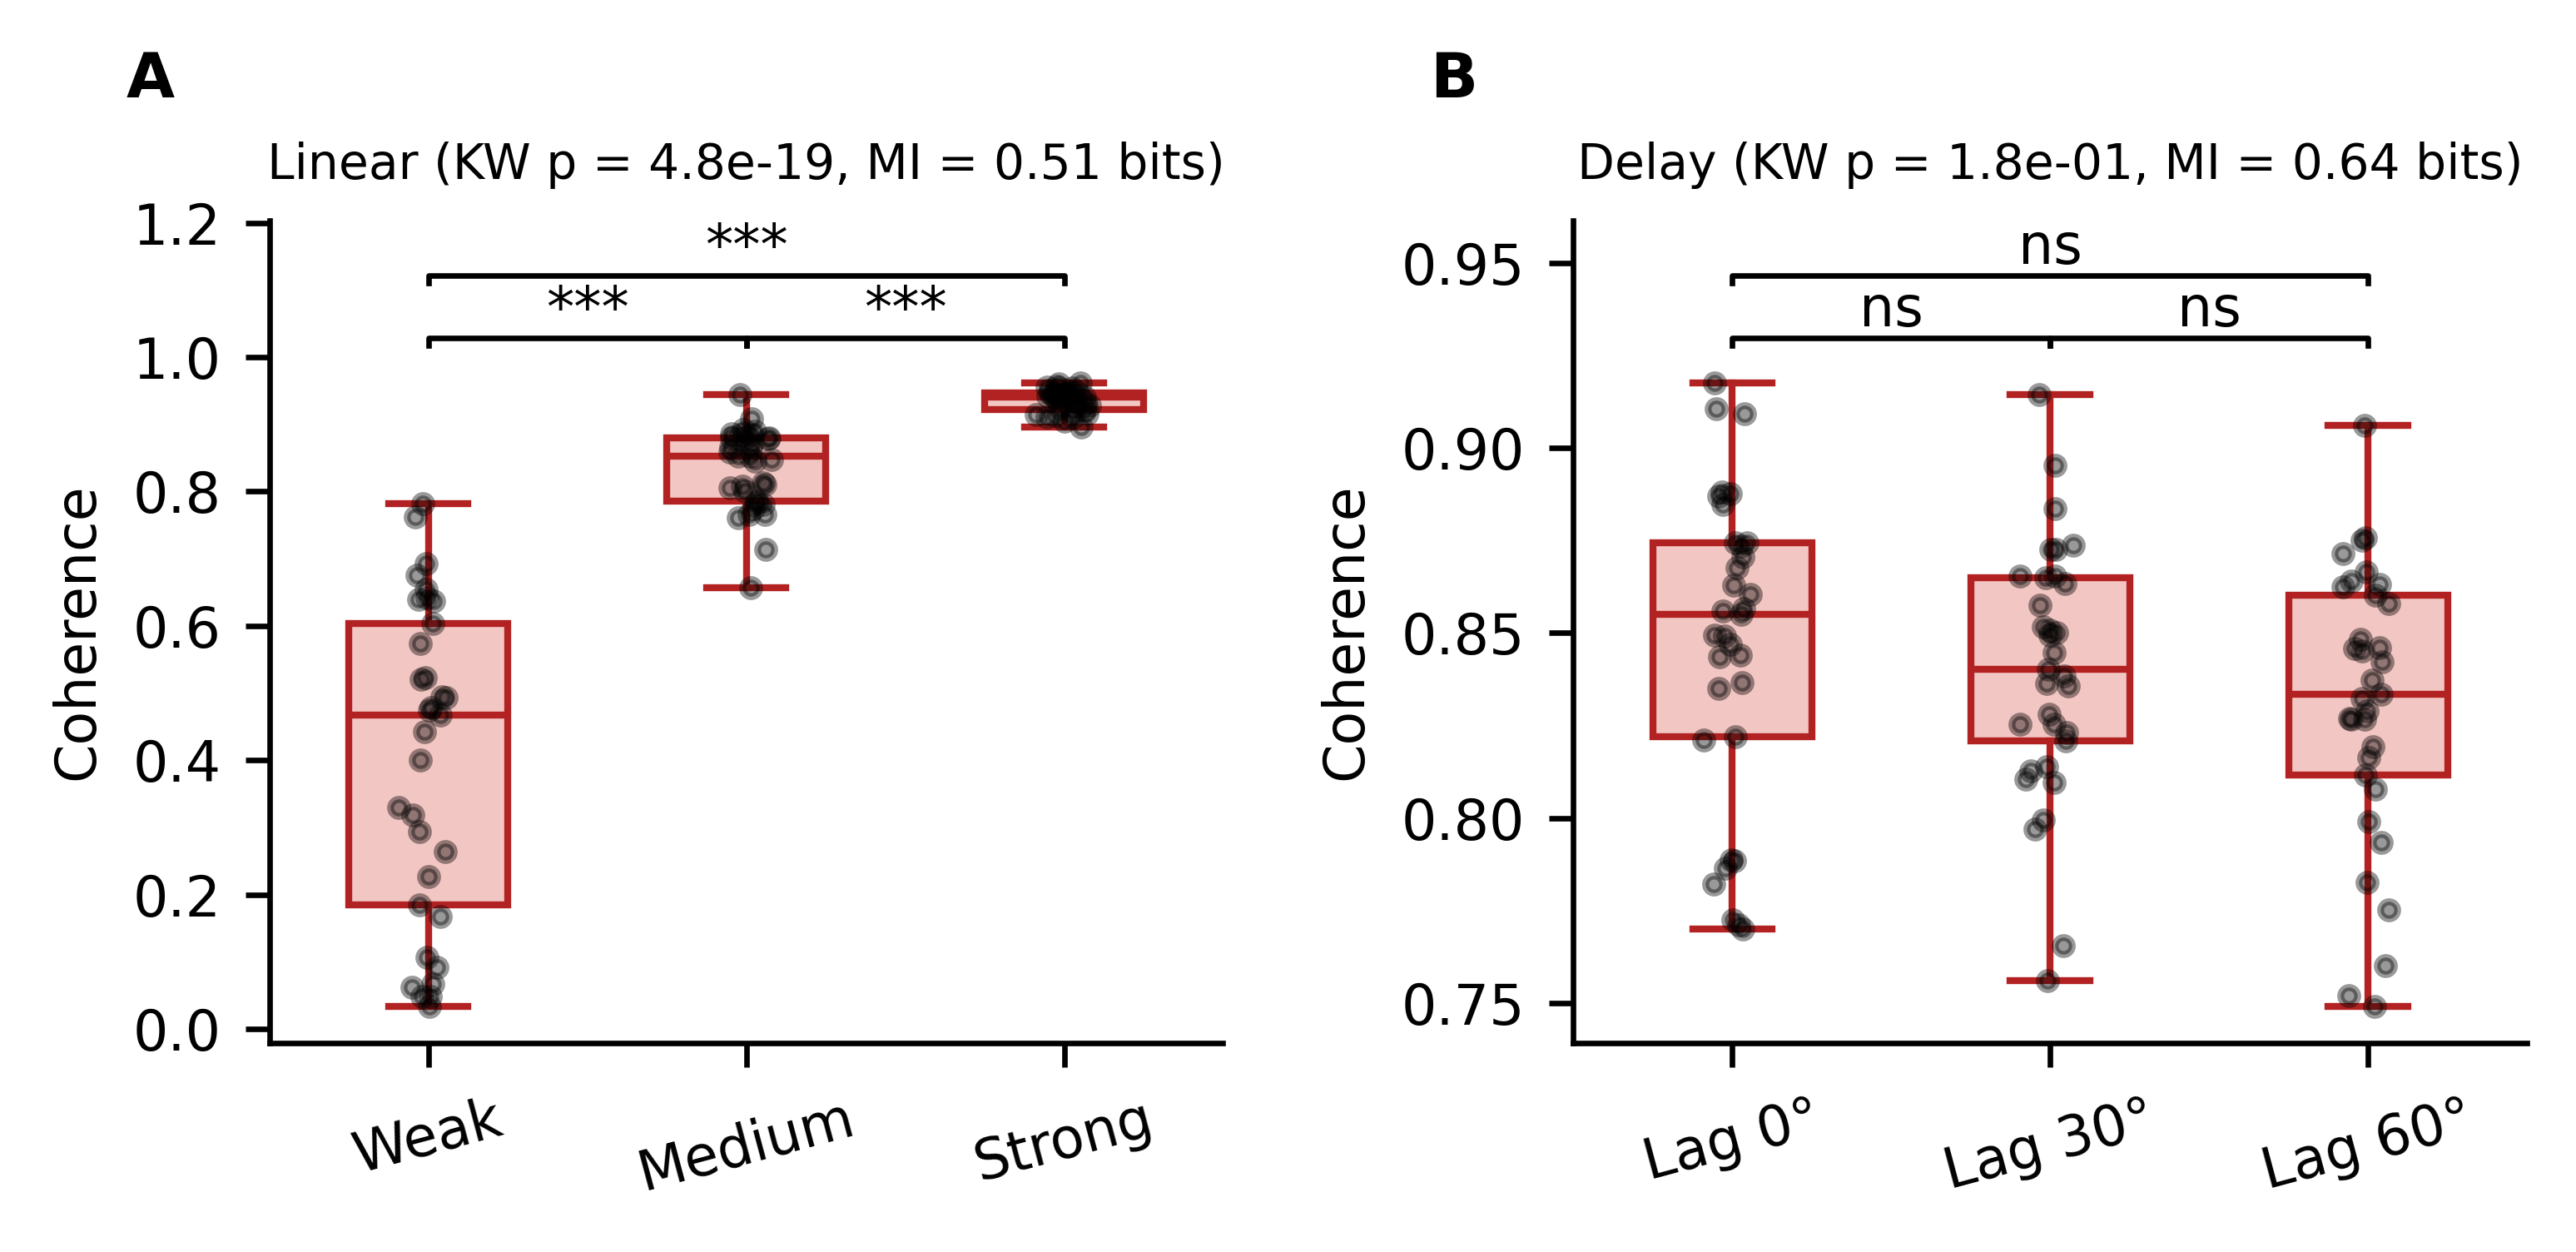

In [ ]:
def sig_label(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"

regressor_by_regime = {"Linear": CS, "Delay": lag_label}
regressor_label = {"Linear": "CS", "Delay": "Lag [°]"}
trial_idx = np.arange(ntrials)

fig1s = plt.figure(figsize=(5.2, 2.6), dpi=600)
rng_jitter = np.random.default_rng(0)
axes1s = []

for i, regime in enumerate(["Linear", "Delay"]):
    ax = fig1s.add_subplot(1, 2, i + 1)
    axes1s.append(ax)
    coh_by_group = coh_by_regime[regime]
    pairwise_p = pairwise_p_by_regime[regime]
    pairs = pairs_by_regime[regime]
    names = list(coh_by_group.keys())
    box_data = [coh_by_group[n] for n in names]

    bp = ax.boxplot(box_data, tick_labels=names, widths=0.5, showfliers=False, patch_artist=True)
    for patch in bp["boxes"]:
        patch.set_facecolor("#f2c6c2")
        patch.set_edgecolor("firebrick")
    for element in ["whiskers", "caps", "medians"]:
        for line in bp[element]:
            line.set_color("firebrick")
    ax.tick_params(axis="x", labelrotation=15)

    for j, n in enumerate(names):
        x = rng_jitter.normal(j + 1, 0.04, size=len(coh_by_group[n]))
        ax.scatter(x, coh_by_group[n], s=6, color="k", alpha=0.4, zorder=3)

    ax.set_ylabel("Coherence")
    ax.set_title(
        f"{regime} (KW p = {kw_results[regime][1]:.1e}, MI = {mi_by_regime[regime]:.2f} bits)",
        fontsize=SMALL_SIZE - 1,
    )
    [ax.spines[key].set_visible(False) for key in ["top", "right"]]

    # Significance brackets
    y_max = max(v.max() for v in coh_by_group.values())
    y_min = min(v.min() for v in coh_by_group.values())
    y_range = y_max - y_min
    bracket_specs = [(1, 2, 0.06), (2, 3, 0.06), (1, 3, 0.16)]

    for (a, b), (x1, x2, h_mult) in zip(pairs, bracket_specs):
        y = y_max + h_mult * y_range
        tick = 0.012 * y_range
        ax.plot([x1, x1, x2, x2], [y, y + tick, y + tick, y], color="k", lw=0.8)
        ax.text((x1 + x2) / 2, y + tick, sig_label(pairwise_p[(a, b)]),
                ha="center", va="bottom", fontsize=SMALL_SIZE)

    ax.set_ylim(top=y_max + 0.26 * y_range)

   
plot.add_panel_letters(fig1s, axes=axes1s, fontsize=MEDIUM_SIZE, xpos=-0.15, ypos=1.15)

plt.tight_layout()
plt.savefig("../figures/Figure1S.pdf")

### Supplementary Figure 1S caption

Figure 1S: Coherence requires coarse trial-binning to reveal any stimulus dependence, and it can be completely blind to a regressor that clearly changes the underlying dynamics. (A, "Linear") Ground-truth two-node Kuramoto simulation (n = 1000 trials) with tonic coupling proportional to a coupling parameter CS spanning near-zero to strongly synchronizing (inset: CS vs. trial); trials split into terciles by coupling strength (Weak/Medium/Strong, n ≈ 333 each). (B, "Delay") A second simulation with coupling strength held fixed while only the inter-node transmission delay varies across three blocks, corresponding to phase lags of 0°, 30°, and 60° at the natural frequency (inset: lag vs. trial) — chosen to stay well inside the regime where the delayed coupling's restoring force (∝ cos of the phase lag) remains strongly stabilizing, so that locking quality itself does not change across conditions. In both panels, consecutive groups of 10 trials within each condition were pooled to estimate a coherence value (35–45 Hz, 0–0.4 s window), yielding a distribution of ~33 coherence estimates per condition — coherence cannot be computed from a single trial, so this kind of discretization is unavoidable if coherence is the summary statistic being related to the stimulus. Boxplots show the resulting distributions; significance was assessed with a Kruskal–Wallis omnibus test (title) followed by pairwise Mann–Whitney U tests (Bonferroni-corrected for 3 comparisons; brackets). Titles also report MI between the (band/window-averaged) phase relationship and each panel's regressor, using the (real, imag) parts of the averaged cross-spectrum as a 2-feature representation for both panels (avoiding the wraparound problems a rank-based estimator has with a single circular variable, and keeping the two panels methodologically consistent).

In Panel A, the coupling-to-coherence relationship saturates, so Medium and Strong can become statistically indistinguishable even though their coupling amplitudes differ substantially. Panel B makes the point more starkly: coherence depends only on how concentrated the trial-to-trial phase difference is, not on its mean angle, so it is mathematically insensitive to a constant phase rotation — with the delay kept inside the stable-locking regime, the three conditions show statistically indistinguishable coherence despite being clearly different physical conditions, while MI computed on the (real, imag) representation of the phase relationship recovers the lag. This is the requested case where coherence is the same but the regressor is different, made concrete: a coherence/correlation-based summary misses it entirely, while a phase-resolved, information-theoretic measure (MI/PID) does not. (Note: pushing the delay toward 90°/180° instead reveals a second, complementary point — delay-coupled oscillators can lose lock quality entirely as the coupling's local restoring force weakens and flips sign, which coherence *does* pick up, but for the wrong reason: it reflects a genuine change in synchronization, not a controlled manipulation of the regressor alone.)